## Nandini Jaiswal MDS202335

## Import Necessary Libraries

In [ ]:
import os
import json
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

## Setting up working and writing directories for `pdf-json` input


In [ ]:
writing_dir = "/kaggle/working/"
working_dir = "/kaggle/input/"
os.chdir(os.path.join(working_dir, "pdf-json/"))

### Assignment 7 - Extracting Abstracts from JSON Files with Multiprocessing (Corpus creation)

The code below processes JSON files to extract abstracts using multiprocessing. Here's a brief overview of the steps:

1. **Abstract Extraction**:
   - The `extract_abstract` function reads a JSON file, extracts the abstract text, and generates a local vocabulary of unique words (excluding single characters and symbols).

2. **Saving Extracted Abstracts**:
   - The `save_abstract` function writes the extracted abstract to a text file in a specified output directory.

3. **Parallel Processing**:
   - The `handle_all_files_parallel` function utilizes Python's multiprocessing pool to process multiple JSON files simultaneously.

4. **Input and Output**:
   - JSON files are read from the `input_directory` (`pdf_json`), and the extracted abstracts are saved in the `output_directory` as text files.

In [ ]:
# Function to handle a single JSON file and retrieve the abstract
def extract_abstract(file_location):
    try:
        with open(file_location, 'r', encoding='utf-8') as json_file:
            json_data = json.load(json_file)
            abstract_data = json_data.get('abstract', [])
            if abstract_data:
                # Combine all parts of the abstract into one string
                combined_abstract = ' '.join([section['text'] for section in abstract_data])
                abstract_line = combined_abstract
                # Create a local set of unique words for this file, excluding single characters and symbols
                vocab_set = set(
                    word for word in abstract_line.split() if len(word) > 1 and word.isalpha()
                )
                return file_location, combined_abstract, vocab_set
    except Exception as error:
        print(f"Error processing file {file_location}: {error}")
    return file_location, None, set()

# Helper function to save abstracts to output files
def save_abstract(output_data):
    source_file, abstract_content, _ = output_data
    if abstract_content is not None:
        target_file_path = os.path.join(
            output_directory, f"{os.path.splitext(os.path.basename(source_file))[0]}-abstract.txt"
        )
        with open(target_file_path, 'w', encoding='utf-8') as output_writer:
            output_writer.write(abstract_content)

# Main function to handle all JSON files in a directory using multiprocessing
def handle_all_files_parallel(input_directory, output_directory):
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Gather all JSON file paths
    json_files = [
        os.path.join(input_directory, json_file_name)
        for json_file_name in os.listdir(input_directory)
        if json_file_name.endswith('.json')
    ]

    # Use a pool of workers to process files with tqdm for progress tracking
    with Pool(cpu_count()) as workers_pool:
        for output in tqdm(
            workers_pool.imap_unordered(extract_abstract, json_files),
            total=len(json_files),
            desc="Processing JSON files"
        ):
            save_abstract(output)

input_directory = 'pdf_json'
output_directory = os.path.join(writing_dir, 'abstract_texts')

handle_all_files_parallel(input_directory, output_directory)


Processing files: 100%|██████████| 56528/56528 [00:10<00:00, 5389.69it/s] 


## Defining a `DataLoader` class for `abstracts` retrieval

In [ ]:
# Check for GPU availability
hardware_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {hardware_device}")

# Custom Dataset to load text files from 'abstract_texts' folder
class AbstractTextDataset(Dataset):
    def __init__(self, directory_path):
        max_file_count = 56528
        self.abstract_file_paths = [
            os.path.join(directory_path, file_name)
            for file_name in os.listdir(directory_path)
            if file_name.endswith('.txt')
        ][:max_file_count]
        self.full_text = []

        # Load and combine abstract text data
        for file_path in self.abstract_file_paths:
            with open(file_path, 'r', encoding='utf-8') as abstract_file:
                content = abstract_file.read().lower()  # Normalize by converting to lowercase
                self.full_text.append(content)

        # Combine all abstracts for the dataset
        self.full_text = ' '.join(self.full_text)
        self.tokens = self.full_text.split()  # Split text into individual words
        self.unique_vocab = sorted(set(self.tokens))  # Create a vocabulary of unique words
        self.token_to_index = {token: index for index, token in enumerate(self.unique_vocab)}
        self.index_to_token = {index: token for index, token in enumerate(self.unique_vocab)}

    def __len__(self):
        return len(self.tokens) - 1  # Last token doesn't have a following pair

    def __getitem__(self, index):
        input_token = self.token_to_index[self.tokens[index]]
        target_token = self.token_to_index[self.tokens[index + 1]]
        return torch.tensor(input_token, dtype=torch.long), torch.tensor(target_token, dtype=torch.long)

# Assignment 6

### Architecture of the Language Model

The language model follows a sequential structure, designed to predict the next word in a given sequen. The model has two hidden states consisting of a forward and
backward pas. e. Its architecture includes the following components:

1. **Embedding Layer**:  
   This layer maps input tokens (words) into dense vector representations of a fixed dimension (`embedding_dim`). This reduces the dimensionality and captures semantic relationships between words.

2. **LSTM Layer**:  
   A two-layer Long Short-Term Memory (LSTM) network is used for processing sequential data. It takes the embedded input and models dependencies in the sequence, preserving context over long ranges. The hidden dimension (`hidden_dim`) determines the capacity of the model to learn patterns.

3. **Linear Output Layer**:  
   The output from the LSTM is passed through a fully connected linear layer. This layer maps the LSTM's output to a vector of size equal to the vocabulary, representing the predicted probabilities for the next token.

4. **Activation and Loss Function**:  
   The final predictions are converted to probabilities using softmax (implicitly in `CrossEntropyLoss` during training). The loss function, `CrossEntropyLoss`, is used to compare the predicted token probabilities with the actual next token.

5. **Training Flow**:  
   During training, sequences of words are fed into the model, which predicts the next word iteratively. The model updates its weights using backpropagation with the Adam optimizer, aiming to minimize the p context is crucial.

In [ ]:
# Hyperparameters
embedding_dim = 50  # Size of embeddings
hidden_dim = 128
num_lstm_layers = 2
training_epochs = 16
learning_rate_value = 0.008
batch_size_value = 1024

# Load dataset and create data loader
abstract_dataset = AbstractTextDataset(directory_path=os.path.join(writing_dir, 'abstract_texts'))
abstract_loader = DataLoader(
    abstract_dataset,
    batch_size=batch_size_value,
    shuffle=True,
    num_workers=4,
    prefetch_factor=2
)

# Define the Language Model
class AbstractLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_lstm_layers):
        super(AbstractLanguageModel, self).__init__()
        self.embedding_layer = nn.Embedding(vocab_size, embedding_dim)
        self.lstm_layer = nn.LSTM(embedding_dim, hidden_dim, num_lstm_layers, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_sequence, hidden_state):
        embedded_input = self.embedding_layer(input_sequence)  # Shape: [batch_size, seq_length, embedding_dim]
        lstm_output, hidden_state = self.lstm_layer(embedded_input, hidden_state)  # Shape: [batch_size, seq_length, hidden_dim]
        predictions = self.output_layer(lstm_output)  # Shape: [batch_size, seq_length, vocab_size]
        return predictions, hidden_state

# Model instantiation
vocab_count = len(abstract_dataset.unique_vocab)
language_model = AbstractLanguageModel(vocab_count, embedding_dim, hidden_dim, num_lstm_layers).to(hardware_device)

# Loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer_instance = optim.Adam(language_model.parameters(), lr=learning_rate_value)


Using device: cuda


# Assignment 7

### Explanation of the Training Process

The training function iteratively updates the weights of the language model to minimize the loss, following these steps:

1. The dataset is loaded in batches using a DataLoader. Each batch consists of input tokens and their corresponding target tokens.

2. For each batch, the hidden and cell states of the LSTM are dynamically initialized to zeros, ensuring independence between batches.

3. The input tokens are passed through the model to generate predictions for the next tokens in the sequence. These predictions are reshaped for compatibility with the loss function.

4. The loss is calculated using `CrossEntropyLoss`, comparing the predicted token probabilities with the actual target tokens.

5. Gradients are computed using backpropagation, and the optimizer updates the model's weights to reduce the loss.

6. The cumulative loss for all batches in an epoch is averaged and stored to monitor training progress.

7. A plot is generated to show the change in training loss over epochs, providing insight into the model's learning performance.

### `NOTE`:
The model has been trained for 16 epochs considering all the abstract files.

Epoch 1/16: 100%|██████████| 4458/4458 [05:18<00:00, 13.99it/s]


Epoch [1/16], Loss: 7.1344


Epoch 2/16: 100%|██████████| 4458/4458 [05:18<00:00, 14.00it/s]


Epoch [2/16], Loss: 6.4537


Epoch 3/16: 100%|██████████| 4458/4458 [05:17<00:00, 14.06it/s]


...

Epoch [14/16], Loss: 5.5033


Epoch 15/16: 100%|██████████| 4458/4458 [05:21<00:00, 13.88it/s]


Epoch [15/16], Loss: 5.4968


Epoch 16/16: 100%|██████████| 4458/4458 [05:19<00:00, 13.95it/s]


Epoch [16/16], Loss: 5.4925


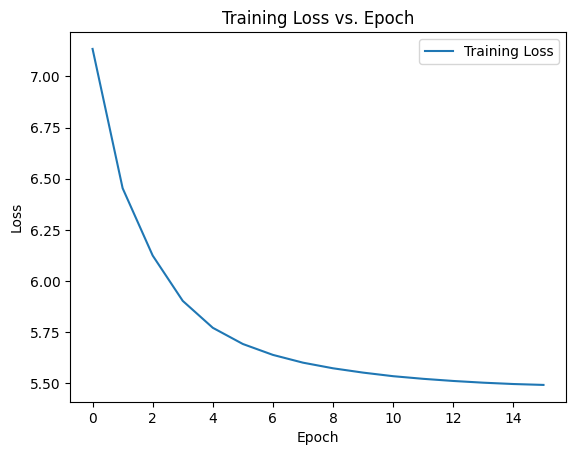

In [ ]:
# Training function with loss tracking
training_loss_history = []
for epoch_index in range(training_epochs):
    cumulative_epoch_loss = 0

    for batch_index, (input_batch, target_batch) in enumerate(
        tqdm(abstract_loader, desc=f"Epoch {epoch_index + 1}/{training_epochs}")
    ):
        input_batch = input_batch.to(hardware_device).unsqueeze(1)  # Add a sequence length dimension: [batch_size, 1]
        target_batch = target_batch.to(hardware_device)

        # Initialize hidden states dynamically for each batch
        hidden_state = (
            torch.zeros(num_lstm_layers, input_batch.size(0), hidden_dim).to(hardware_device),
            torch.zeros(num_lstm_layers, input_batch.size(0), hidden_dim).to(hardware_device)
        )

        # Forward pass
        predictions, hidden_state = language_model(input_batch, hidden_state)

        # Reshape predictions to 2D for CrossEntropyLoss
        batch_loss = loss_function(predictions.view(-1, vocab_count), target_batch.view(-1))

        # Backpropagation
        optimizer_instance.zero_grad()
        batch_loss.backward()
        optimizer_instance.step()

        cumulative_epoch_loss += batch_loss.item()

    # Calculate average loss for the epoch
    average_epoch_loss = cumulative_epoch_loss / len(abstract_loader)
    training_loss_history.append(average_epoch_loss)
    print(f"Epoch [{epoch_index + 1}/{training_epochs}], Loss: {average_epoch_loss:.4f}")

# Plotting training loss graph
plt.plot(training_loss_history, label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs. Epoch")
plt.legend()
plt.show()


# Assignment 8

# Abstract generation using the trained model

### Text Generation with Temperature-Based Sampling

The code below generates abstracts using the trained language model with temperature-based sampling. Here's a detailed explanation of the code:

1. The model is set to evaluation mode to disable dropout and other training-specific behaviors.

2. The input seed text which will be the first word of generated abstract (e.g., "The") is tokenized into words and converted into indices using the model's vocabulary. These indices are then transformed into a tensor.

3. The LSTM's hidden and cell states are initialized to zero for the text generation process.

4. For each word in the generated sequence (up to a specified maximum length), the model predicts the next word based on the input sequence. Temperature scaling is applied to the output logits, influencing the randomness of the word selection:
   - **Lower Temperature** (e.g., 0.4): Leads to more deterministic and coherent text.
   - **Higher Temperature**: Results in more diverse and random text.
   
   The predicted word index is sampled from the probability distribution and added to the generated text.

5. The input sequence is updated with the newly predicted word for the next iteration of generation.

6. The generated abstract is printed after generating a sequence of words, with the temperature controlling the diversity and coherence of the text.d coherence of the text.

# Sample generated abstracts with first word `The`

In [ ]:
# Function to generate text (abstract) with temperature-based sampling
def generate_abstract(language_model, seed_text, max_length=100, sampling_temperature=1.0):
    language_model.eval()  # Set the model to evaluation mode
    generated_abstract = seed_text
    seed_tokens = seed_text.lower().split()  # Tokenize the seed text into words
    seed_indices = [
        abstract_dataset.token_to_index[token]
        for token in seed_tokens if token in abstract_dataset.token_to_index
    ]
    input_sequence = torch.tensor(seed_indices, dtype=torch.long).unsqueeze(0).to(hardware_device)  # Shape [1, seq_length]

    # Initialize hidden states
    hidden_state = (
        torch.zeros(num_lstm_layers, 1, hidden_dim).to(hardware_device),
        torch.zeros(num_lstm_layers, 1, hidden_dim).to(hardware_device)
    )

    for _ in range(max_length):
        with torch.no_grad():
            # Forward pass through the model
            output_logits, hidden_state = language_model(input_sequence, hidden_state)  # Input shape [batch_size, seq_len]
            scaled_logits = output_logits[:, -1, :] / sampling_temperature  # Apply temperature scaling
            probability_distribution = torch.nn.functional.softmax(scaled_logits, dim=-1)  # Convert logits to probabilities
            sampled_index = torch.multinomial(probability_distribution, 1).item()  # Sample an index from the distribution

        # Retrieve the predicted word
        predicted_token = abstract_dataset.index_to_token[sampled_index]
        generated_abstract += " " + predicted_token

        # Update the input sequence for the next iteration
        input_sequence = torch.tensor([[sampled_index]], dtype=torch.long).to(hardware_device)  # Shape [1, 1]

    return generated_abstract + "."

# Generate abstracts with sampling
for abstract_index in range(6):
    seed_text = "The"
    generated_sample_abstract = generate_abstract(
        language_model, seed_text, max_length=100, sampling_temperature=0.4  # Lower temperature for more coherent text
    )
    print(f"Generated Abstract {abstract_index + 1}:\n{generated_sample_abstract}\n")


Generated Abstract 1:
The downstream epidemiological impacts of the infection of the infection in the most types of the hospitalized patients with an isolated from emerged in china. these a 0-7 an even when the number one of the effective in china, the pandemic in that the increased number of the infection rates of the or in which is the older age and many healthcare is often are, a severe fetal abnormalities results at the terms of the virus and to compare these patients, individuals in the number of the epidemic or in severe acute illnesses. specific surface was replication. because they could provide.

Generated Abstract 2:
The range of the previous studies as for the literature is associated to the lockdown respiratory viral pathogens was to identify the results provide a major public health care systems which was protein taken from the number one of all four of the human data and the impact in the patient care. and the spread and the model was the period due to be the novel corona

# Sample generated abstracts with first two words `The virus`

In [ ]:
# Function to generate text (abstract) with temperature-based sampling
def generate_abstract(language_model, seed_text, max_length=100, sampling_temperature=1.0):
    language_model.eval()  # Set the model to evaluation mode
    generated_abstract = seed_text
    seed_tokens = seed_text.lower().split()  # Tokenize the seed text into words
    seed_indices = [
        abstract_dataset.token_to_index[token]
        for token in seed_tokens if token in abstract_dataset.token_to_index
    ]
    input_sequence = torch.tensor(seed_indices, dtype=torch.long).unsqueeze(0).to(hardware_device)  # Shape [1, seq_length]

    # Initialize hidden states
    hidden_state = (
        torch.zeros(num_lstm_layers, 1, hidden_dim).to(hardware_device),
        torch.zeros(num_lstm_layers, 1, hidden_dim).to(hardware_device)
    )

    for _ in range(max_length):
        with torch.no_grad():
            # Forward pass through the model
            output_logits, hidden_state = language_model(input_sequence, hidden_state)  # Input shape [batch_size, seq_len]
            scaled_logits = output_logits[:, -1, :] / sampling_temperature  # Apply temperature scaling
            probability_distribution = torch.nn.functional.softmax(scaled_logits, dim=-1)  # Convert logits to probabilities
            sampled_index = torch.multinomial(probability_distribution, 1).item()  # Sample an index from the distribution

        # Retrieve the predicted word
        predicted_token = abstract_dataset.index_to_token[sampled_index]
        generated_abstract += " " + predicted_token

        # Update the input sequence for the next iteration
        input_sequence = torch.tensor([[sampled_index]], dtype=torch.long).to(hardware_device)  # Shape [1, 1]

    return generated_abstract + "."

# Generate abstracts with sampling
for abstract_index in range(6):
    seed_text = "The virus"
    generated_sample_abstract = generate_abstract(
        language_model, seed_text, max_length=100, sampling_temperature=0.4  # Lower temperature for more coherent text
    )
    print(f"Generated Abstract {abstract_index + 1}:\n{generated_sample_abstract}\n")


Generated Abstract 1:
The virus and the covid-19 cases in the global health crisis and the spread propaganda and vomiting. we were used to the the first cases will have increased (bun, a total of a high and the covid-19 patients were male, of the covid-19 patients were included. a robust viral genome sequences is of the and the first patients and has been used f, shi days). the human and the detection stomach and the clinical characteristics and hispanic individuals who in a nodules. comprehending representation of the and to produce a large variety recalls of the the major public health diabetics and and.

Generated Abstract 2:
The virus entry and of circsfl degenerate pcr (weight of the to the time series of the covid-19 pandemic is that of the new insights into the sars-cov-2 antibody was not in a total tonsils) nicht. wurde die auf die de la pandemia sobre un estudio de la pandemia por estudio de la mortalidad el que el que se han et les plus de la adquisición un punto van de la in

# Sample generated abstracts with first two words `The pandemic`

In [ ]:
# Function to generate text (abstract) with temperature-based sampling
def generate_abstract(language_model, seed_text, max_length=100, sampling_temperature=1.0):
    language_model.eval()  # Set the model to evaluation mode
    generated_abstract = seed_text
    seed_tokens = seed_text.lower().split()  # Tokenize the seed text into words
    seed_indices = [
        abstract_dataset.token_to_index[token]
        for token in seed_tokens if token in abstract_dataset.token_to_index
    ]
    input_sequence = torch.tensor(seed_indices, dtype=torch.long).unsqueeze(0).to(hardware_device)  # Shape [1, seq_length]

    # Initialize hidden states
    hidden_state = (
        torch.zeros(num_lstm_layers, 1, hidden_dim).to(hardware_device),
        torch.zeros(num_lstm_layers, 1, hidden_dim).to(hardware_device)
    )

    for _ in range(max_length):
        with torch.no_grad():
            # Forward pass through the model
            output_logits, hidden_state = language_model(input_sequence, hidden_state)  # Input shape [batch_size, seq_len]
            scaled_logits = output_logits[:, -1, :] / sampling_temperature  # Apply temperature scaling
            probability_distribution = torch.nn.functional.softmax(scaled_logits, dim=-1)  # Convert logits to probabilities
            sampled_index = torch.multinomial(probability_distribution, 1).item()  # Sample an index from the distribution

        # Retrieve the predicted word
        predicted_token = abstract_dataset.index_to_token[sampled_index]
        generated_abstract += " " + predicted_token

        # Update the input sequence for the next iteration
        input_sequence = torch.tensor([[sampled_index]], dtype=torch.long).to(hardware_device)  # Shape [1, 1]

    return generated_abstract + "."

# Generate abstracts with sampling
for abstract_index in range(6):
    seed_text = "The pandemic"
    generated_sample_abstract = generate_abstract(
        language_model, seed_text, max_length=100, sampling_temperature=0.4  # Lower temperature for more coherent text
    )
    print(f"Generated Abstract {abstract_index + 1}:\n{generated_sample_abstract}\n")


Generated Abstract 1:
The pandemic has been reported a total of the lockdown of covid-19 pandemic, but it has been developed. in the total of covid-19 pneumonia and a clinical parameters (mtase) activity and ethnopharmacological (middle du and quality of the control measures were more effective for novel antiviral drugs and to may be easily used chicago dan niet de la revisión die es wurden der zu einer von de la infección und die de la infección der postnatalen de les principales de las personas de la infección der pandemie es una delle vie au de and the potential risk factors for the analysis of.

Generated Abstract 2:
The pandemic risk of the covid-19 is the current evidence approach to validate the time pcr, especially doctors, and asians and the development and of the reduction in the development and the development and pid city, the conceptual energy range of the nucleocapsid (n) protein and the efficacy ej, jorgensen cells and to develop a 5-week spinal hurricane endothelial dys

# Sample generated abstracts with first two words `The paper`

In [ ]:
# Function to generate text (abstract) with temperature-based sampling
def generate_abstract(language_model, seed_text, max_length=100, sampling_temperature=1.0):
    language_model.eval()  # Set the model to evaluation mode
    generated_abstract = seed_text
    seed_tokens = seed_text.lower().split()  # Tokenize the seed text into words
    seed_indices = [
        abstract_dataset.token_to_index[token]
        for token in seed_tokens if token in abstract_dataset.token_to_index
    ]
    input_sequence = torch.tensor(seed_indices, dtype=torch.long).unsqueeze(0).to(hardware_device)  # Shape [1, seq_length]

    # Initialize hidden states
    hidden_state = (
        torch.zeros(num_lstm_layers, 1, hidden_dim).to(hardware_device),
        torch.zeros(num_lstm_layers, 1, hidden_dim).to(hardware_device)
    )

    for _ in range(max_length):
        with torch.no_grad():
            # Forward pass through the model
            output_logits, hidden_state = language_model(input_sequence, hidden_state)  # Input shape [batch_size, seq_len]
            scaled_logits = output_logits[:, -1, :] / sampling_temperature  # Apply temperature scaling
            probability_distribution = torch.nn.functional.softmax(scaled_logits, dim=-1)  # Convert logits to probabilities
            sampled_index = torch.multinomial(probability_distribution, 1).item()  # Sample an index from the distribution

        # Retrieve the predicted word
        predicted_token = abstract_dataset.index_to_token[sampled_index]
        generated_abstract += " " + predicted_token

        # Update the input sequence for the next iteration
        input_sequence = torch.tensor([[sampled_index]], dtype=torch.long).to(hardware_device)  # Shape [1, 1]

    return generated_abstract + "."

# Generate abstracts with sampling
for abstract_index in range(6):
    seed_text = "The paper"
    generated_sample_abstract = generate_abstract(
        language_model, seed_text, max_length=100, sampling_temperature=0.4  # Lower temperature for more coherent text
    )
    print(f"Generated Abstract {abstract_index + 1}:\n{generated_sample_abstract}\n")


Generated Abstract 1:
The paper addresses the most and the two american cities in the most of the covid-19 pandemic has been reported that the promising alternative to the most of the virus infection in the potential risk factors for the majority of the major challenge [or and the need multifaceted approach to of the novel coronavirus disease 2019 (covid-19) pandemic poses that the to the use in ventilated (cdc), world is the wide range protein of multi-level frameworks. supplements are of the human respiratory syndrome coronavirus disease in the first (26.9%) and viral particles in the novel coronavirus infections in the development of the.

Generated Abstract 2:
The paper is a number a1, ntpase/helicase and and the efficacy (ar), j o o o u r e d soni et la dopamine ships. the and the population statement: we perform a high risk of hepatozoon kinase and the major cause severe acute respiratory disease 2019 (covid-19) and the sars-cov-2 spike transfection. in the same time and to be of

# Discussion of the results

The generated abstracts exhibit some meaningful keywords and phrases (e.g., "COVID-19", "vaccination", "antibodies") relevant to the seed text, but overall coherence and grammar are suboptimal.

### Possible Reasons for Sub-Optimal Results and Suggestions for Improvement

1. **Limited Training Data**:
   - **Issue**: The model has been trained on a limited dataset which leads to poor generalization, as the model may not capture a diverse range of language patterns, especially if the dataset is not representative of the target distribution.
   - **Solution**: Increase the size of the dataset by incorporating more diverse sources, such as additional abstracts from other domains or data augmentation techniques like paraphrasing or back-translation. Fine-tuning the model with domain-specific datasets can also improve its performance.

2. **Different Languages Used**:
   - **Issue**: Mixed languages in a dataset can hinder model performance. When a dataset contains text in multiple languages, each language may have its own vocabulary, grammar, and syntax. The model might struggle to learn a coherent representation of words if they are mixed, leading to inconsistencies in vocabulary and meaning. The model might unintentionally learn cross-language patterns or associations, especially in the case of similar words across languages.
The model might as well fail to understand different sentence structures and grammatical rules of different languages, leading to errors in sentence generation or understanding.
   - **Solution**:Preprocess the dataset to separate text by language, ensuring each language has its own vocabulary and model. This helps the model focus on learning language-specific patterns and syntax, reducing confusion caused by mixed languages. Language identification tools can be used to automate this process.
     
4. **Inadequate Model Complexity**:
   - **Issue**: The current model is be too simple (with only two hidden layers) to capture complex patterns in the data. This results in underfitting, where the model fails to learn important linguistic features.
   - **Solution**: Experiment with increasing the model's complexity by using more layers, increasing the hidden state dimension, or using more sophisticated architectures like GRUs or attention mechanisms. Cross-validation and hyperparameter tuning (e.g., learning rate, batch size) can help find the optimal configuration.


By addressing these factors through data augmentation, model tuning, parameter optimization, and language segmentation, the performance and quality of the generated text can be significantly improved.ntly improved.